# 🌿 Plant Disease Detection using RT-DETR
This notebook trains **RT-DETR (Real-Time Detection Transformer)** on the PlantVillage dataset for plant disease detection.

**Dataset:** `emmarex/plantdisease` from Kaggle (15 plant disease classes)

**Pipeline:**
1. Download dataset via `kagglehub`
2. Convert classification-format images to YOLO detection format
3. Train RT-DETR using Ultralytics
4. Visualize training metrics

## 1. Install Dependencies

In [1]:
# Install required packages
!pip install -q ultralytics kagglehub opencv-python matplotlib scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.2 MB/s eta 0:00:00


## 2. Import Libraries

In [2]:
import os
import shutil
import random
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import RTDETR

# Reproducibility
random.seed(42)
np.random.seed(42)

print("✅ Libraries imported successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries imported successfully


In [3]:
!nvidia-smi

Tue Apr  7 13:34:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# ── CUDA / GPU Setup ───────────────────────────────────────────────────────
import torch

# Check CUDA availability
if torch.cuda.is_available():
    DEVICE = 'cuda'
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem  = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f'✅ GPU detected  : {gpu_name}')
    print(f'   VRAM          : {gpu_mem:.1f} GB')
    print(f'   CUDA version  : {torch.version.cuda}')
    print(f'   cuDNN enabled : {torch.backends.cudnn.enabled}')
    # Enable cuDNN auto-tuner for faster convolutions
    torch.backends.cudnn.benchmark = True
else:
    DEVICE = 'cpu'
    print('Warning: No GPU found - training will run on CPU (slow).')

print(f'Device selected: {DEVICE}')


✅ GPU detected  : Tesla T4
   VRAM          : 14.6 GB
   CUDA version  : 12.8
   cuDNN enabled : True
Device selected: cuda


In [5]:
# ── CUDA / GPU Setup ───────────────────────────────────────────────────────
import torch

# Check CUDA availability
if torch.cuda.is_available():
    DEVICE = "cuda"
    gpu_name  = torch.cuda.get_device_name(0)
    gpu_mem   = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"✅ GPU detected  : {gpu_name}")
    print(f"   VRAM          : {gpu_mem:.1f} GB")
    print(f"   CUDA version  : {torch.version.cuda}")
    print(f"   cuDNN enabled : {torch.backends.cudnn.enabled}")
    # Enable cuDNN auto-tuner for faster convolutions
    torch.backends.cudnn.benchmark = True
else:
    DEVICE = "cpu"
    print("⚠️  No GPU found – training will run on CPU (slow).")

print(f"\n🚀 Device selected: {DEVICE}")


✅ GPU detected  : Tesla T4
   VRAM          : 14.6 GB
   CUDA version  : 12.8
   cuDNN enabled : True

🚀 Device selected: cuda


## 3. Download the PlantVillage Dataset

In [6]:
import kagglehub

# Download the PlantVillage dataset
print("📥 Downloading PlantVillage dataset...")
dataset_path = kagglehub.dataset_download("emmarex/plantdisease")
print(f"✅ Dataset downloaded to: {dataset_path}")

📥 Downloading PlantVillage dataset...
Using Colab cache for faster access to the 'plantdisease' dataset.
✅ Dataset downloaded to: /kaggle/input/plantdisease


## 4. Explore Dataset Structure

In [7]:
# Explore the dataset
print(f"📂 Dataset root: {dataset_path}")

# Find all plant folders
all_entries = os.listdir(dataset_path)
print(f"\nTop-level entries: {all_entries}")

# Gather all disease classes
CLASS_NAMES = []
IMAGE_PATHS = {}  # class_name -> list of image paths

for entry in sorted(all_entries):
    entry_path = os.path.join(dataset_path, entry)
    if os.path.isdir(entry_path):
        sub_entries = os.listdir(entry_path)
        # Check if subdirectory contains images or sub-folders (class folders)
        for sub in sorted(sub_entries):
            sub_path = os.path.join(entry_path, sub)
            if os.path.isdir(sub_path) and sub not in ('.DS_Store',):
                imgs = [f for f in os.listdir(sub_path)
                        if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                if imgs:
                    CLASS_NAMES.append(sub)
                    IMAGE_PATHS[sub] = [os.path.join(sub_path, f) for f in imgs]

print(f"\n📊 Total classes found: {len(CLASS_NAMES)}")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  [{i:02d}] {cls}: {len(IMAGE_PATHS[cls])} images")

📂 Dataset root: /kaggle/input/plantdisease

Top-level entries: ['PlantVillage', 'plantvillage']

📊 Total classes found: 15
  [00] Pepper__bell___Bacterial_spot: 997 images
  [01] Pepper__bell___healthy: 1478 images
  [02] Potato___Early_blight: 1000 images
  [03] Potato___Late_blight: 1000 images
  [04] Potato___healthy: 152 images
  [05] Tomato_Bacterial_spot: 2127 images
  [06] Tomato_Early_blight: 1000 images
  [07] Tomato_Late_blight: 1909 images
  [08] Tomato_Leaf_Mold: 952 images
  [09] Tomato_Septoria_leaf_spot: 1771 images
  [10] Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
  [11] Tomato__Target_Spot: 1404 images
  [12] Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
  [13] Tomato__Tomato_mosaic_virus: 373 images
  [14] Tomato_healthy: 1591 images


## 5. Convert to YOLO Detection Format

RT-DETR (and all Ultralytics detection models) require images with corresponding `.txt` label files.
Each label file contains one row per object: `class_id x_center y_center width height` (all normalized 0–1).

Since this is a **classification** dataset (no bounding box annotations), we generate a single full-image bounding box per image:
`class_id 0.5 0.5 1.0 1.0` — the box covers 100% of the image, centered at (0.5, 0.5).

In [8]:
# ── Configuration ───────────────────────────────────────────────────────────
DATASET_DIR  = Path("plant_disease_yolo")   # output dir for YOLO-format data
TRAIN_RATIO  = 0.80                         # 80 % train, 20 % val
MAX_PER_CLASS = 600                         # cap images per class (memory & speed)
IMG_SIZE     = 640                          # RT-DETR input resolution

# ── Build directory tree ─────────────────────────────────────────────────────
for split in ("train", "val"):
    (DATASET_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (DATASET_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("📁 YOLO directory structure created")

# ── Copy images and write label files ───────────────────────────────────────
total_train, total_val = 0, 0

for cls_id, cls_name in enumerate(tqdm(CLASS_NAMES, desc="Processing classes")):
    imgs = IMAGE_PATHS[cls_name]
    random.shuffle(imgs)
    imgs = imgs[:MAX_PER_CLASS]             # cap images

    train_imgs, val_imgs = train_test_split(imgs, train_size=TRAIN_RATIO, random_state=42)

    for split, split_imgs in (("train", train_imgs), ("val", val_imgs)):
        for src_path in split_imgs:
            stem = Path(src_path).stem
            # Use class + stem to avoid name collisions across classes
            unique_name = f"{cls_id:02d}_{cls_name[:20]}_{stem}"

            dst_img = DATASET_DIR / "images" / split / f"{unique_name}.jpg"
            dst_lbl = DATASET_DIR / "labels" / split / f"{unique_name}.txt"

            # Copy image
            shutil.copy2(src_path, dst_img)

            # Write full-image bounding box label
            with open(dst_lbl, "w") as f:
                f.write(f"{cls_id} 0.5 0.5 1.0 1.0\n")

    total_train += len(train_imgs)
    total_val   += len(val_imgs)

print(f"\n✅ Dataset prepared:  {total_train} train  |  {total_val} val images")

📁 YOLO directory structure created


Processing classes: 100%|██████████| 15/15 [00:58<00:00,  3.88s/it]


✅ Dataset prepared:  6659 train  |  1666 val images


## 6. Create YAML Configuration for RT-DETR

In [9]:
# Build the dataset YAML
yaml_content = {
    "path": str(DATASET_DIR.resolve()),
    "train": "images/train",
    "val":   "images/val",
    "nc":    len(CLASS_NAMES),
    "names": CLASS_NAMES
}

yaml_path = DATASET_DIR / "plant_disease.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(yaml_content, f, default_flow_style=False, sort_keys=False)

print("📄 YAML config written to:", yaml_path)
print("-" * 50)
with open(yaml_path) as f:
    print(f.read())

📄 YAML config written to: plant_disease_yolo/plant_disease.yaml
--------------------------------------------------
path: /content/plant_disease_yolo
train: images/train
val: images/val
nc: 15
names:
- Pepper__bell___Bacterial_spot
- Pepper__bell___healthy
- Potato___Early_blight
- Potato___Late_blight
- Potato___healthy
- Tomato_Bacterial_spot
- Tomato_Early_blight
- Tomato_Late_blight
- Tomato_Leaf_Mold
- Tomato_Septoria_leaf_spot
- Tomato_Spider_mites_Two_spotted_spider_mite
- Tomato__Target_Spot
- Tomato__Tomato_YellowLeaf__Curl_Virus
- Tomato__Tomato_mosaic_virus
- Tomato_healthy



## 7. Visualise Sample Images

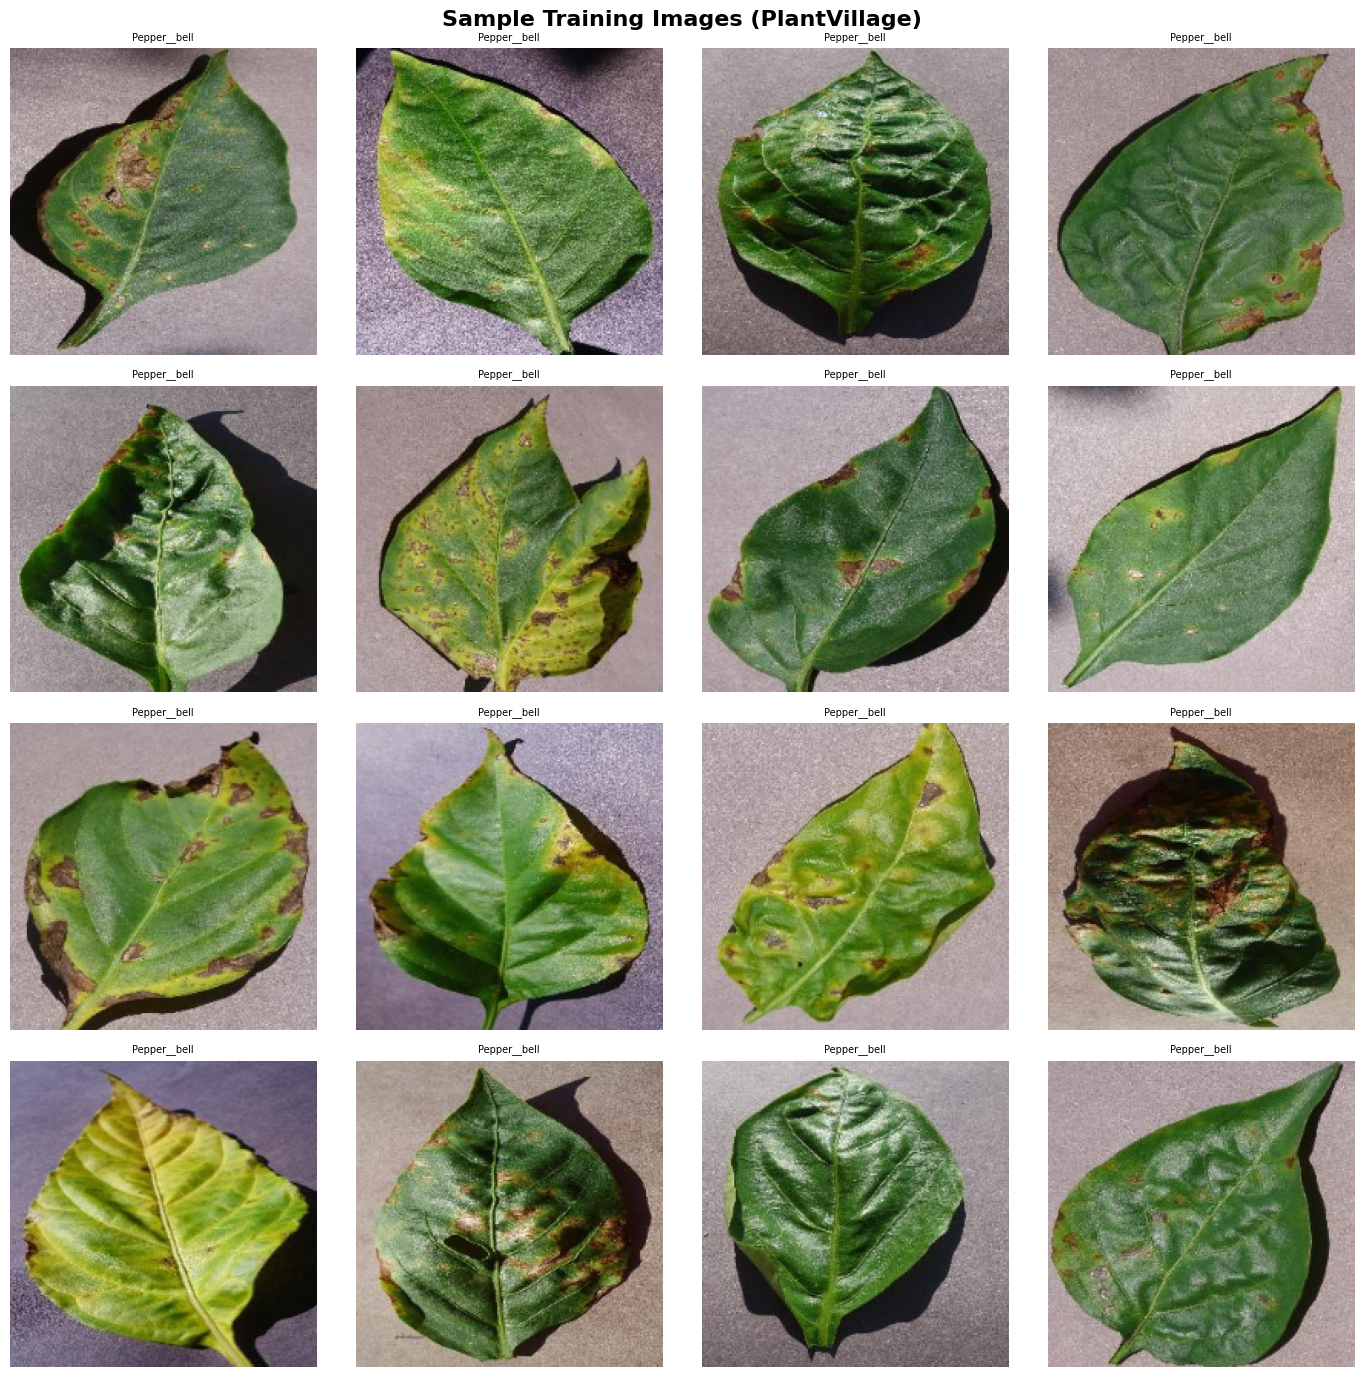

✅ Sample images saved to sample_training_images.png


In [10]:
# Show a grid of sample training images
train_imgs_list = sorted((DATASET_DIR / "images" / "train").glob("*.jpg"))[:16]

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle("Sample Training Images (PlantVillage)", fontsize=16, fontweight="bold")

for ax, img_path in zip(axes.flatten(), train_imgs_list):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (200, 200))
    ax.imshow(img)
    # Extract class name from filename
    label = "_".join(img_path.stem.split("_")[1:4])
    ax.set_title(label[:22], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.savefig("sample_training_images.png", dpi=100, bbox_inches="tight")
plt.show()
print("✅ Sample images saved to sample_training_images.png")

## 8. Train RT-DETR

We use **RT-DETR-L** (Large variant) pretrained on COCO, and fine-tune it on our plant disease dataset.

**Key hyper-parameters:**
| Parameter | Value | Reason |
|-----------|-------|--------|
| `epochs` | 50 | Good trade-off between convergence and time |
| `imgsz` | 640 | Standard RT-DETR input size |
| `batch` | 16 | Adjust down if you run out of VRAM |
| `optimizer` | AdamW | Best for transformers |
| `lr0` | 1e-4 | Conservative LR for fine-tuning |
| `lrf` | 0.01 | Cosine LR decay to 1% of initial |
| `warmup_epochs` | 3 | Avoids early instability |
| `augment` | True | Mosaic, flip, HSV augmentation |
| `patience` | 15 | Early stopping if no improvement |
| `exist_ok` | True | Resume-friendly |

In [11]:
# ── Load RT-DETR-L (pretrained on COCO, will auto-download weights) ──────────
model = RTDETR("rtdetr-l.pt")

print("🚀 Starting RT-DETR training on Plant Disease dataset...")
print(f"   Classes   : {len(CLASS_NAMES)}")
print(f"   Train imgs: {total_train}")
print(f"   Val imgs  : {total_val}")
print("=" * 60)

results = model.train(
    device=DEVICE,
    data        = str(yaml_path),
    epochs      = 25,
    imgsz       = 640,
    batch       = 16,            # lower to 8 if GPU OOM
    optimizer   = "AdamW",
    lr0         = 1e-4,
    lrf         = 0.01,
    warmup_epochs = 3,
    momentum    = 0.9,
    weight_decay = 1e-4,
    augment     = True,
    hsv_h       = 0.015,
    hsv_s       = 0.7,
    hsv_v       = 0.4,
    flipud      = 0.2,
    fliplr      = 0.5,
    degrees     = 10.0,
    translate   = 0.1,
    scale       = 0.5,
    patience    = 15,            # early stopping
    save        = True,
    save_period = 10,
    project     = "plant_disease_rtdetr",
    name        = "rtdetr_l_run",
    exist_ok    = True,
    verbose     = True,
)

print("\n✅ Training complete!")

🚀 Starting RT-DETR training on Plant Disease dataset...
   Classes   : 15
   Train imgs: 6659
   Val imgs  : 1666
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=plant_disease_yolo/plant_disease.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.2, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.9, mosaic=1.0, multi_scale=0.0, 

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/25      1.54G     0.1644      3.114     0.2283         11        640: 100% ━━━━━━━━━━━━ 417/417 1.2s/it 8:36
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 1.3it/s 39.4s
                   all       1666       1666      0.134      0.198    0.00184    0.00112

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/25      12.6G    0.08311      1.828     0.1168         10        640: 100% ━━━━━━━━━━━━ 417/417 1.1s/it 7:47
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 1.7it/s 31.2s
                   all       1666       1666      0.238      0.386      0.156      0.153

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


...

      23/25      12.5G   0.004332    0.03949    0.00922          3        640: 100% ━━━━━━━━━━━━ 417/417 1.1s/it 7:51
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 1.7it/s 32.0s
                   all       1666       1666      0.994      0.997      0.994      0.994

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      24/25      12.7G   0.004205    0.03787   0.008886          3        640: 100% ━━━━━━━━━━━━ 417/417 1.1s/it 7:52
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 1.7it/s 31.9s
                   all       1666       1666      0.995      0.996      0.993      0.993

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      25/25      12.4G   0.004194    0.03722   0.009007          3        640: 100% ━━━━━━━━━━━━ 417/417 1.1s/it 7:53
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 1.7it/s 32.0s
                   all       1666       1666      0.995      0.998      0.994      0.994

25 epochs completed in 3.592 hours.
Optimizer stripped from /content/runs/detect/plant_disease_rtdetr/rtdetr_l_run/weights/last.pt, 66.3MB
Optimizer stripped from /content/runs/detect/plant_disease_rtdetr/rtdetr_l_run/weights/best.pt, 66.3MB

Validating /content/runs/detect/plant_disease_rtdetr/rtdetr_l_run/weights/best.pt...
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 32,014,565 parameters, 0 gradients, 103.5 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 53/53 1.6it/s 32.7s
                   all       1666       1666 

## 9. Evaluate on Validation Set

In [12]:
# Run validation and print metrics
print("📊 Running validation...")
val_results = model.val(
    data    = str(yaml_path),
    imgsz   = 640,
    batch   = 16,
    verbose = True,
)

print("\n" + "=" * 50)
print("📈 Validation Results Summary")
print("=" * 50)
print(f"  mAP50       : {val_results.box.map50:.4f}")
print(f"  mAP50-95    : {val_results.box.map:.4f}")
print(f"  Precision   : {val_results.box.mp:.4f}")
print(f"  Recall      : {val_results.box.mr:.4f}")

📊 Running validation...
Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 32,014,565 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 849.6±266.1 MB/s, size: 16.4 KB)
val: Scanning /content/plant_disease_yolo/labels/val.cache... 1666 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1666/1666 698.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 105/105 1.4it/s 1:17
                   all       1666       1666      0.996      0.994      0.994      0.994
Pepper__bell___Bacterial_spot        120        120          1          1      0.995      0.995
Pepper__bell___healthy        120        120          1      0.982      0.985      0.985
 Potato___Early_blight        120        120      0.999          1      0.995      0.995
  Potato___Late_blight        120        120          1      0.992      0.995      0.995
    

## 10. Plot Training Metrics

Columns: ['epoch', 'time', 'train/giou_loss', 'train/cls_loss', 'train/l1_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/giou_loss', 'val/cls_loss', 'val/l1_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


/tmp/ipykernel_356/3274762691.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


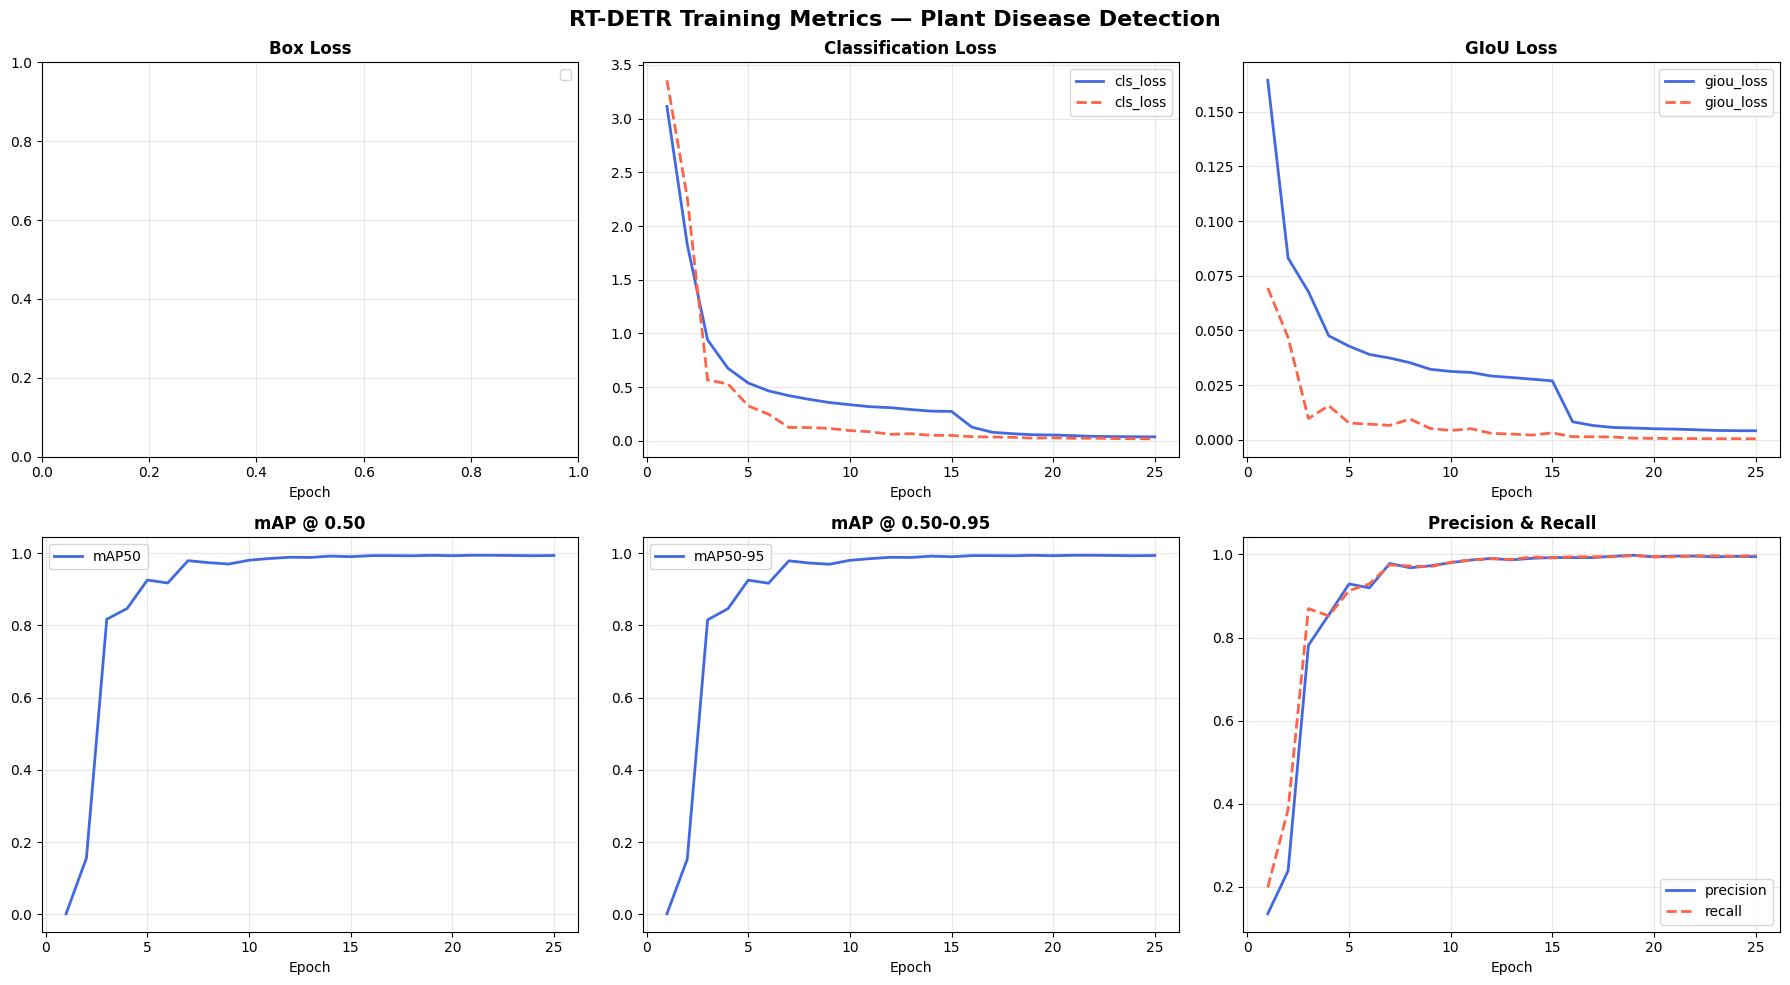

✅ Metrics plot saved to rtdetr_training_metrics.png


In [13]:
import pandas as pd

# Load training CSV results
results_csv = Path("runs/detect/plant_disease_rtdetr/rtdetr_l_run/results.csv")

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # strip whitespace from column names
    print("Columns:", df.columns.tolist())

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("RT-DETR Training Metrics — Plant Disease Detection",
                 fontsize=16, fontweight="bold")

    # Define metric plots
    metric_map = [
        ("train/box_loss",    "val/box_loss",    "Box Loss",           axes[0, 0]),
        ("train/cls_loss",    "val/cls_loss",    "Classification Loss", axes[0, 1]),
        ("train/giou_loss",   "val/giou_loss",   "GIoU Loss",          axes[0, 2]),
        ("metrics/mAP50(B)",  None,              "mAP @ 0.50",         axes[1, 0]),
        ("metrics/mAP50-95(B)", None,            "mAP @ 0.50-0.95",    axes[1, 1]),
        ("metrics/precision(B)", "metrics/recall(B)", "Precision & Recall", axes[1, 2])
    ]

    epochs = df["epoch"] if "epoch" in df.columns else range(len(df))

    for train_col, val_col, title, ax in metric_map:
        if train_col in df.columns:
            ax.plot(epochs, df[train_col], label=train_col.split("/")[-1].replace("(B)",""),
                    color="royalblue", linewidth=2)
        if val_col and val_col in df.columns:
            ax.plot(epochs, df[val_col], label=val_col.split("/")[-1].replace("(B)",""),
                    color="tomato", linewidth=2, linestyle="--")
        ax.set_title(title, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("rtdetr_training_metrics.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("✅ Metrics plot saved to rtdetr_training_metrics.png")
else:
    print(f"⚠️  results.csv not found at {results_csv}. Check your training output folder.")

## 11. Save Best Model Info

In [15]:
best_model_path = Path("runs/detect/plant_disease_rtdetr/rtdetr_l_run/weights/best.pt")

if best_model_path.exists():
    size_mb = best_model_path.stat().st_size / (1024 ** 2)
    print(f"🏆 Best model saved at : {best_model_path}")
    print(f"   File size           : {size_mb:.1f} MB")
    print(f"   Classes             : {len(CLASS_NAMES)}")
    print(f"   mAP50               : {val_results.box.map50:.4f}")
    print(f"   mAP50-95            : {val_results.box.map:.4f}")
else:
    print("⚠️  best.pt not found — check your training run output.")

print("\n🎉 Done! RT-DETR training pipeline complete.")

🏆 Best model saved at : runs/detect/plant_disease_rtdetr/rtdetr_l_run/weights/best.pt
   File size           : 63.2 MB
   Classes             : 15
   mAP50               : 0.9943
   mAP50-95            : 0.9943

🎉 Done! RT-DETR training pipeline complete.
